#  Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час. Постройте модель для такого предсказания.

Значение метрики *RMSE* на тестовой выборке должно быть не больше 48.

Вам нужно:

1. Загрузить данные и выполнить их ресемплирование по одному часу.
2. Проанализировать данные.
3. Обучить разные модели с различными гиперпараметрами. Сделать тестовую выборку размером 10% от исходных данных.
4. Проверить данные на тестовой выборке и сделать выводы.


Данные лежат в файле `taxi.csv`. Количество заказов находится в столбце `num_orders` (от англ. *number of orders*, «число заказов»).

In [1]:
pip install --upgrade scikit-learn -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import re
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from statsmodels.tsa.seasonal import seasonal_decompose
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 52
TEST_SIZE = 0.25

## Загрузка данных

In [3]:
data = pd.read_csv("taxi.csv", index_col=[0], parse_dates=[0])
data.sort_index(inplace=True)
data.head()

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


In [5]:
data = data.resample('1H').sum()

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: h
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB


При выгрузке данных сделал так, чтобы столбец со временем стал индексом, привел его к datetime64. В изначальных данных было 26496 строк (временной промежуток между строками = 10мин), сразу провел ресемплирования с суммированием, теперь в данных 4416 строк (временной промежуток между строками = 1 час).

## Подготовка

Предобработка с таким времянным рядом не нужна, но для обучения моделей в будущем необходимо создать новые столбцы.

### Создание признаков.

In [7]:
columns = []
df = data.copy()
def make_features(data, max_lag, rolling_mean_size):
    df['month'] = data.index.month
    df['day'] = data.index.day
    df['dayofweek'] = data.index.dayofweek
    
    for lag in range(1, max_lag + 1):
        df['lag_{}'.format(lag)] = df['num_orders'].shift(lag)
        columns.append('lag_{}'.format(lag))
        df['rolling_mean'] = df['num_orders'].shift().rolling(rolling_mean_size).mean()
        return df, columns
# Подбор параметров для функции make_features
make_features(data, max_lag=24, rolling_mean_size=10)


(                     num_orders  month  day  dayofweek  lag_1  rolling_mean
 datetime                                                                   
 2018-03-01 00:00:00         124      3    1          3    NaN           NaN
 2018-03-01 01:00:00          85      3    1          3  124.0           NaN
 2018-03-01 02:00:00          71      3    1          3   85.0           NaN
 2018-03-01 03:00:00          66      3    1          3   71.0           NaN
 2018-03-01 04:00:00          43      3    1          3   66.0           NaN
 ...                         ...    ...  ...        ...    ...           ...
 2018-08-31 19:00:00         136      8   31          4  207.0         173.3
 2018-08-31 20:00:00         154      8   31          4  136.0         166.6
 2018-08-31 21:00:00         159      8   31          4  154.0         162.9
 2018-08-31 22:00:00         223      8   31          4  159.0         162.1
 2018-08-31 23:00:00         205      8   31          4  223.0         170.8

В датафрейм были добавлены столбцы с: номером месяца,номером дня, днем недели,скользящее среднее без текущего значения и "отстающие значеия"

## Анализ

In [8]:
df.groupby('month').median()['num_orders']

month
3     55.0
4     61.0
5     71.0
6     83.0
7     98.0
8    122.0
Name: num_orders, dtype: float64

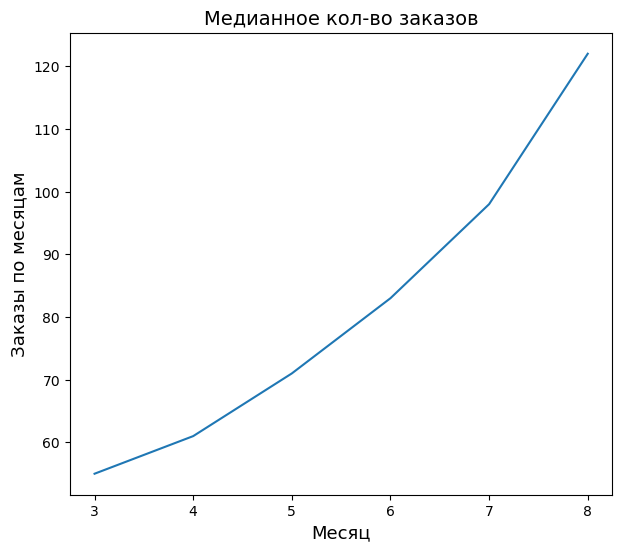

In [9]:
df.groupby('month').median()['num_orders'].plot(figsize = (7,6), rot = 0)
plt.xlabel('Месяц',fontsize=13)
plt.title('Медианное кол-во заказов', fontsize=14)
plt.ylabel('Заказы по месяцам',fontsize=13);

На графике можно увидеть, что с кажыдм последующим месяцем кол-во заказов становится больше, и в нашей выборке это является трендом, но вполне можно предположить, что если бы у нас была базза данных за больший период, подобное развитие стало бы сезонностью, ведь люди чаще улетают в конце лета.

In [10]:
df.groupby('dayofweek').median()['num_orders']

dayofweek
0    81.5
1    72.5
2    80.0
3    78.0
4    87.0
5    76.0
6    75.5
Name: num_orders, dtype: float64

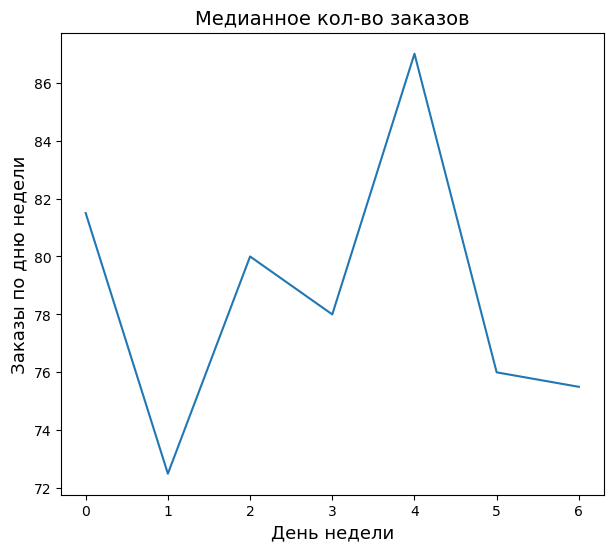

In [11]:
df.groupby('dayofweek').median()['num_orders'].plot(figsize = (7,6), rot = 0)
plt.xlabel('День недели',fontsize=13)
plt.title('Медианное кол-во заказов', fontsize=14)
plt.ylabel('Заказы по дню недели',fontsize=13);

На данном графике можно увидеть, как кол-во заказов увеличивается от вторника к пятнице, что соответсвтует действительности. При это разница между самым высоким и низким значением всего в 15 вызовов. В количественном варианте это не такая уж большая разница, но если говорить о процентном соотношении это довольно весомая группа пользователей.

In [12]:
decomposed = seasonal_decompose(data,period=800)

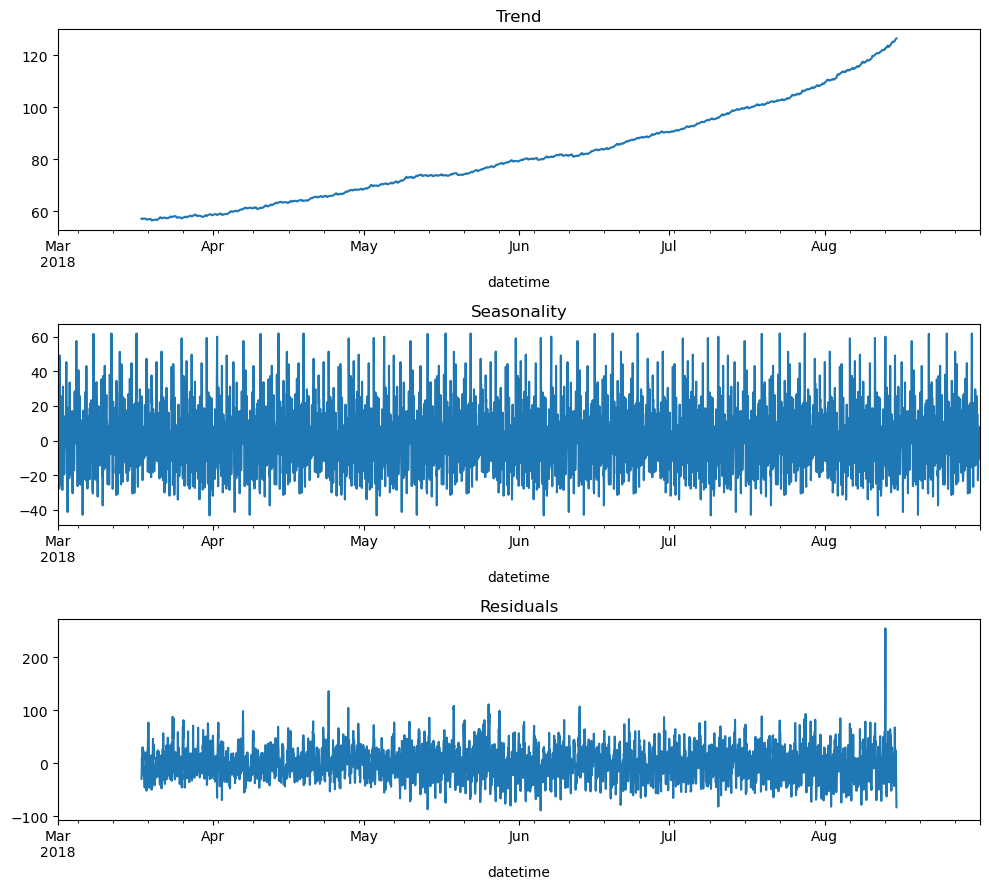

In [13]:
plt.figure(figsize=(10, 9))
plt.subplot(311)
# Чтобы график корректно отобразился, указываем его
# оси ax, равными plt.gca() (англ. get current axis,
# получить текущие оси)
decomposed.trend.plot(ax=plt.gca())
plt.title('Trend')
plt.subplot(312)
decomposed.seasonal.plot(ax=plt.gca()) # < напишите код здесь >
plt.title('Seasonality')
plt.subplot(313)
decomposed.resid.plot(ax=plt.gca()) 
plt.title('Residuals')
plt.tight_layout()

На графике виден тренд роста кол-ва заказов. График сезонности здесь хаотичен, лучше рассмотреть его на более мелком промежутке времени.

In [14]:
decomposed = seasonal_decompose(data['2018-08-01':'2018-08-31'])

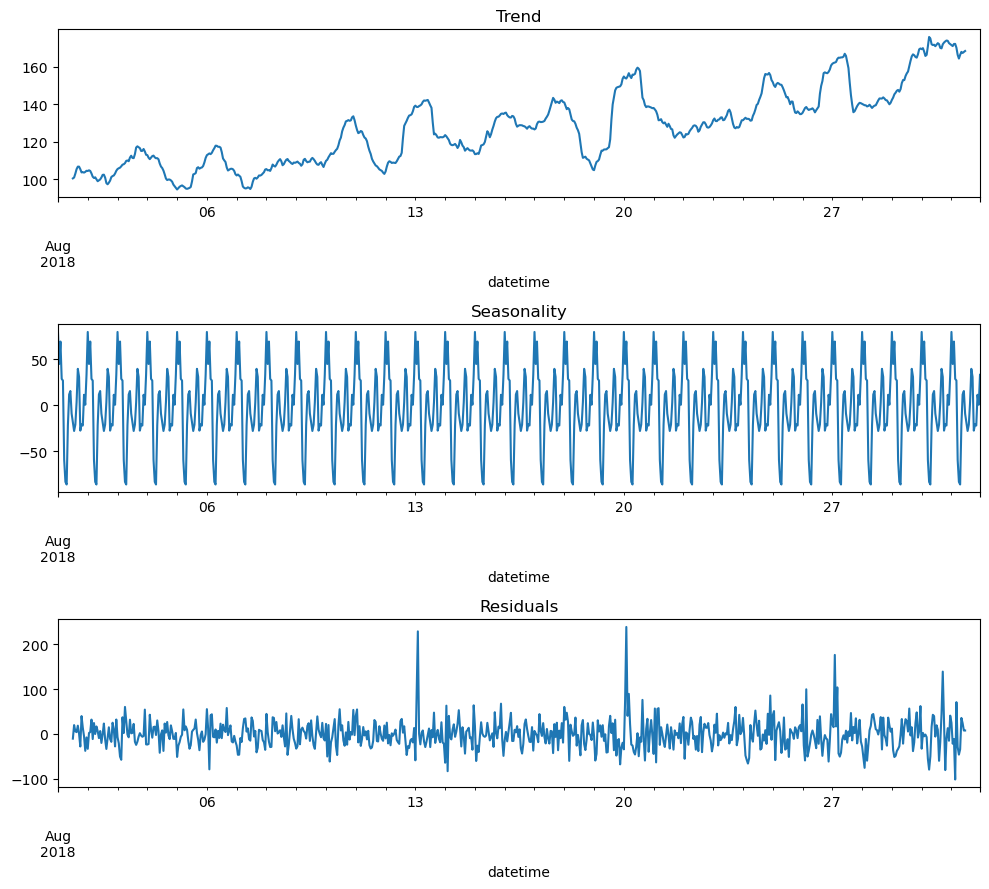

In [15]:
plt.figure(figsize=(10, 9))
plt.subplot(311)
# Чтобы график корректно отобразился, указываем его
# оси ax, равными plt.gca() (англ. get current axis,
# получить текущие оси)
decomposed.trend.plot(ax=plt.gca())
plt.title('Trend')
plt.subplot(312)
decomposed.seasonal.plot(ax=plt.gca()) # < напишите код здесь >
plt.title('Seasonality')
plt.subplot(313)
decomposed.resid.plot(ax=plt.gca()) 
plt.title('Residuals')
plt.tight_layout()

Здесь мы мыожем увидеть сезонность, которая заключается в том, что поздней ночью меньше заказов, чем днем и вечером, что совпадает с действительностью

### Вывод.

С кажыдм последующим месяцем кол-во заказов становится больше, и в нашей выборке это является трендом, но вполне можно предположить, что если бы у нас была базза данных за больший период, подобное развитие стало бы сезонностью, ведь люди чаще улетают в конце лета. Также кол-во заказов увеличивается от вторника к пятнице, что соответсвтует действительности. При это разница между самым высоким и низким значением всего в 15 вызовов. В количественном варианте это не такая уж большая разница, но если говорить о процентном соотношении это все же весомая группа пользователей.Рассматривая график тренда,можно увидеть, что от начала марта до конца августа виден тренд роста кол-ва заказов. Поздней ночью заказов гораздо меньше,чем днем и утром.

## Обучение

In [16]:
X = df.drop(['num_orders'], axis=1)
y = df['num_orders']

# 2.разделим на трейн и тест
X_train, X_test, y_train, y_test = train_test_split(
        X, 
        y, 
        test_size = 0.1, 
        random_state=RANDOM_STATE,
        shuffle=False
    )

ord_columns = ['month', 'day', 'dayofweek']
num_columns = [columns,'rolling_mean']

In [17]:
ord_pipe = Pipeline(
        [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
         ('ord', OrdinalEncoder(
#                                  categories=categories_list
                                handle_unknown='use_encoded_value', unknown_value=np.nan)),
         ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
        ]
    )

    
# 5. общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
                                           [
                                                
                                                ('ord', ord_pipe, ord_columns),
                                            ], 
                                                remainder='passthrough'
                                        )
    
# 5. итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline(
        [   ('preprocessor', data_preprocessor),
            ('models', DecisionTreeRegressor())
        ]
    )

In [18]:
tscv = TimeSeriesSplit()

def rands(param):
    rs_func = RandomizedSearchCV(
    pipe_final, 
    param_distributions=param, 
    scoring='neg_root_mean_squared_error', 
    random_state=RANDOM_STATE,
    n_jobs=-1,
    n_iter=20,
    cv=tscv
    )
    return rs_func

def grids(param):
    gs_func = GridSearchCV(
    pipe_final, 
    param_grid=param, 
    scoring='neg_root_mean_squared_error', 
    n_jobs=-1,
    cv=tscv
    )
    return gs_func

In [19]:
def results(model):
    model.fit(X_train, y_train)
    best_score = model.best_score_
    fit_time = model.cv_results_['mean_fit_time'][model.best_index_]
    score_time = model.cv_results_['mean_score_time'][model.best_index_]
    print('Метрика RMSE для лучшей модели:', best_score)
    print('Время обучения модели:', fit_time)
    print('Время предсказания модели:', score_time)

    
    return model, best_score, fit_time, score_time

In [20]:
param_distributions_dt = {       'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)]
        ,'models__max_depth': range(8, 12)        ,'models__max_features': range(8,11)
    }


In [21]:
dt_model, dt_rmse, dt_fit_time,  dt_score_time=results(grids(param_distributions_dt))

Метрика RMSE для лучшей модели: -38.24594233662905
Время обучения модели: 0.0715552806854248
Время предсказания модели: 0.023363256454467775


In [22]:
param_distributions_rf = {'models': [RandomForestRegressor(random_state=RANDOM_STATE, n_jobs = -1)],
                          'models__max_depth': range(3, 6) ,'models__min_samples_leaf': range(6,8),
                          'models__max_features':(10,12)

     }    

In [23]:
rf_model, rf_rmse, rf_fit_time,  rf_score_time=results(grids(param_distributions_rf))

Метрика RMSE для лучшей модели: -32.49263902434258
Время обучения модели: 0.9593589305877686
Время предсказания модели: 0.31642584800720214


In [24]:
for elem in X.select_dtypes(include = 'object'):
    X[elem]=X[elem].astype('category')
    
# 2.разделим на трейн и тест
X_train, X_test, y_train, y_test = train_test_split(
        X, 
        y, 
        test_size = 0.25, 
        random_state=RANDOM_STATE
    )

При помощи паплайна и перебора парамеров было обучено две лучшие модели: DecisionTreeRegressor и RandomForestRegressor, с метриками RMSE 38.2 и 32.4 соответственно. Время обучения и предсказания моделей прекрсаные (хоть в задании и не написано про оценку данных показателей, но они все равно важны). И исходя из значений метрики RMSE для использования рекомендуется модель случайного леса. 

In [25]:
# 5. итоговый пайплайн: подготовка данных и модель
pipe_final2 = Pipeline(
        [ ('models', LGBMRegressor()) ]
)

# grid_search
def grids2(param):
    gs_func = GridSearchCV(
    pipe_final2, 
    param_grid=param, 
    scoring='neg_root_mean_squared_error', 
    n_jobs=-1,
    cv=5
    )
    return gs_func

## Тестирование

In [26]:
pred = rf_model.predict(X_test)

In [27]:
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
print(f"Root Mean Square Error (RMSE): {rmse}")

Root Mean Square Error (RMSE): 33.38486861259858


Модель случайного леса показала хорошее значение метрики RMSE (33.3) и на тестовой выборке, следовательно она  может использоваться.

In [28]:
rf_model

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'models': [RandomForestR...ndom_state=52)], 'models__max_depth': range(3, 6), 'models__max_features': (10, ...), 'models__min_samples_leaf': range(6, 8)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: 

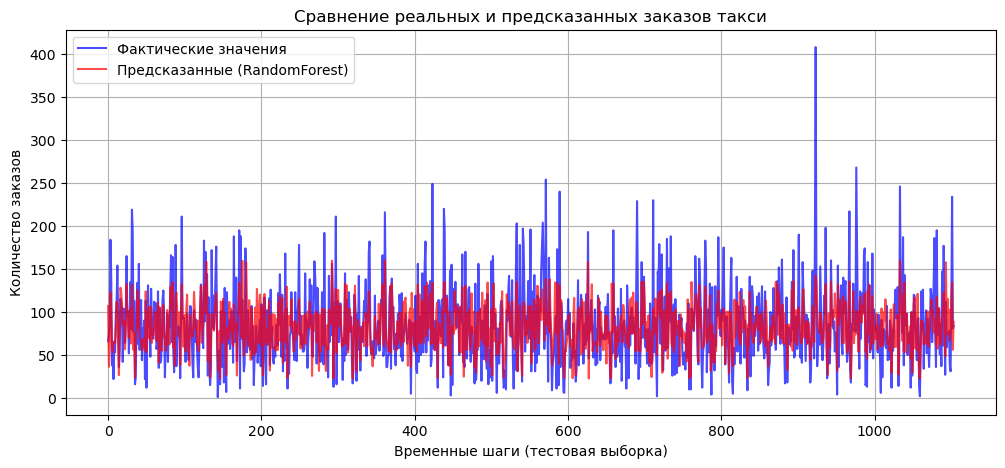

In [30]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Фактические значения', color='blue', alpha=0.7)
plt.plot(pred, label='Предсказанные (RandomForest)', color='red', alpha=0.7)
plt.title('Сравнение реальных и предсказанных заказов такси')
plt.xlabel('Временные шаги (тестовая выборка)')
plt.ylabel('Количество заказов')
plt.legend()
plt.grid(True)
plt.show()

## Общий вывод

Из-за характера полученной базы данных как таковая предобработка не требовалась.При выгрузке данных со временем стал индексом, привел его тип данных к datetime64. В изначальных данных было 26496 строк (временной промежуток между строками = 10мин), сразу провел ресемплирования с суммированием,данных осталось 4416 строк (временной промежуток между строками = 1 час).

В ходе анализа, было выяснено, что с кажыдм последующим месяцем кол-во заказов становится больше, и в нашей выборке это является трендом, но вполне можно предположить, что если бы у нас была базза данных за больший период, подобное развитие стало бы сезонностью, ведь люди чаще улетают в конце лета. Также кол-во заказов увеличивается от вторника к пятнице, что соответсвтует действительности. При это разница между самым высоким и низким значением всего в 15 вызовов. В количественном варианте это не такая уж большая разница, но если говорить о процентном соотношении это все же весомая группа пользователей.

При помощи паплайна и перебора парамеров было обучено две лучшие модели: DecisionTreeRegressor и RandomForestRegressor, с метриками RMSE 38.2 и 32.4 соответственно. Время обучения и предсказания моделей прекрсаные (хоть в задании и не написано про оценку данных показателей, но они все равно важны). И исходя из значений метрики RMSE для использования рекомендуется модель случайного леса.

Модель случайного леса показала хорошее значение метрики RMSE (33.3) и на тестовой выборке, следовательно она может использоваться. Ее параметры:max_depth=4, max_features=10, min_samples_leaf=7.

Для улучшения качества данного исследования, можно было бы сформирвовать базу данных, которая будет охватывать больший промежуток времени, как минимум все 4 сезона в году.